# Uncertainty Quantification in Predictions

Quantifying uncertainty in predictions is crucial for decision-making in subsurface engineering.

**Why Uncertainty Matters:**
- Point estimates alone are insufficient for risk assessment
- Confidence intervals help understand prediction reliability
- Probabilistic forecasts enable better resource planning
- Subsurface properties inherently have high uncertainty

**Topics Covered:**
1. **Loss Functions:** Different ways to measure prediction error
2. **Prediction Distributions:** Characterizing range of possible outcomes
3. **Confidence Intervals:** Quantifying uncertainty bounds
4. **Quantile Regression:** Non-parametric uncertainty estimation
5. **Bayesian Inference:** Updating beliefs with new data

**Applications:**
- Reserve estimation: P10, P50, P90 (pessimistic to optimistic)
- Production forecasting with confidence bands
- Risk-adjusted economic analysis
- Decision support under uncertainty

---

## Comparison of Common Loss Functions

Different loss functions serve different purposes and penalize errors differently.

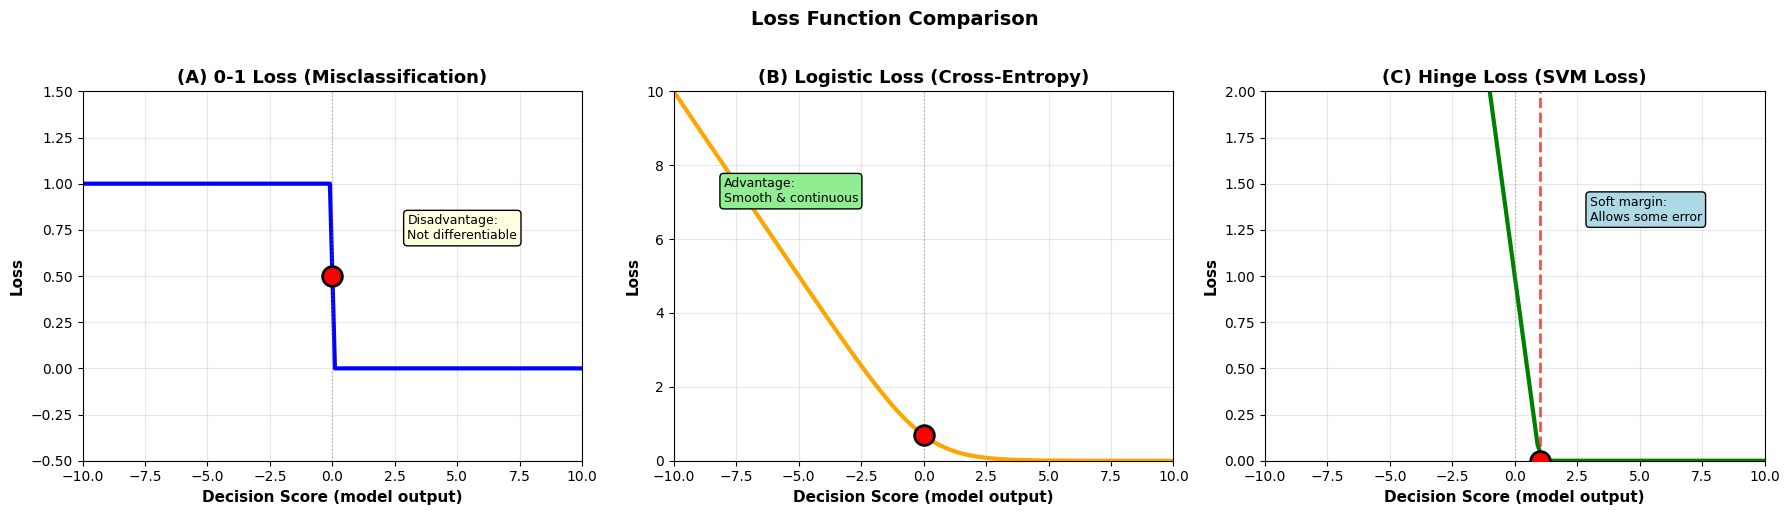

LOSS FUNCTION CHARACTERISTICS:
Loss Type            Differentiable  Use Case                  Best For            
--------------------------------------------------------------------------------
0-1 Loss             No              Accuracy metric           Final evaluation    
Logistic Loss        Yes             Model training            Logistic Regression 
Hinge Loss           Almost          Model training            Support Vector      


In [1]:
"""
Comparison of Loss Functions for Classification
================================================

Three common approaches to measure classification error:

1. 0-1 Loss (Misclassification Error)
   L(y, ŷ) = 0 if y = ŷ, else 1
   • Simplest: counts wrong predictions
   • Discontinuous (hard to optimize)
   • Used for final accuracy metrics

2. Logistic Loss (Binary Cross-Entropy)
   L(y, ŷ) = log(1 + e^(-y×ŷ))
   • Smooth and differentiable
   • Used by Logistic Regression
   • Penalizes confidence in wrong predictions

3. Hinge Loss (SVM Loss)
   L(y, ŷ) = max(0, 1 - y×ŷ)
   • Used by Support Vector Machines
   • Allows margin tolerance
   • Zero loss when prediction is confident and correct
"""

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)

def zero_one_loss(x):
    """0-1 Loss: 1 if x < 0, else 0"""
    return np.where(x < 0, 1, 0)

def logistic_loss(x):
    """Logistic Loss: log(1 + e^(-x))"""
    return np.log(1 + np.exp(-np.clip(x, -100, 100)))

def hinge_loss(x):
    """Hinge Loss: max(0, 1-x)"""
    return np.maximum(0, 1 - x)

y_zero_one = zero_one_loss(x)
y_logistic = logistic_loss(x)
y_hinge = hinge_loss(x)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 0-1 Loss
axes[0].plot(x, y_zero_one, color='blue', linewidth=3)
axes[0].scatter([0], [0.5], s=200, color='red', marker='o', zorder=5, edgecolors='black', linewidth=2)
axes[0].axvline(x=0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
axes[0].set_title("(A) 0-1 Loss (Misclassification)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Decision Score (model output)", fontsize=11, fontweight='bold')
axes[0].set_ylabel("Loss", fontsize=11, fontweight='bold')
axes[0].set_xlim(-10, 10)
axes[0].set_ylim(-0.5, 1.5)
axes[0].grid(True, alpha=0.3)
axes[0].text(3, 0.7, 'Disadvantage:\nNot differentiable', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow'))

# Logistic Loss
axes[1].plot(x, y_logistic, color='orange', linewidth=3)
axes[1].axvline(x=0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
axes[1].scatter([0], [np.log(2)], s=200, color='red', marker='o', zorder=5, 
               edgecolors='black', linewidth=2, label='At x=0')
axes[1].set_title("(B) Logistic Loss (Cross-Entropy)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Decision Score (model output)", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Loss", fontsize=11, fontweight='bold')
axes[1].set_xlim(-10, 10)
axes[1].set_ylim(0, 10)
axes[1].grid(True, alpha=0.3)
axes[1].text(-8, 7, 'Advantage:\nSmooth & continuous', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightgreen'))

# Hinge Loss
axes[2].plot(x, y_hinge, color='green', linewidth=3)
axes[2].axvline(x=0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
axes[2].axvline(x=1, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Margin boundary')
axes[2].scatter([1], [0], s=200, color='red', marker='o', zorder=5, edgecolors='black', linewidth=2)
axes[2].set_title("(C) Hinge Loss (SVM Loss)", fontsize=13, fontweight='bold')
axes[2].set_xlabel("Decision Score (model output)", fontsize=11, fontweight='bold')
axes[2].set_ylabel("Loss", fontsize=11, fontweight='bold')
axes[2].set_xlim(-10, 10)
axes[2].set_ylim(0, 2)
axes[2].grid(True, alpha=0.3)
axes[2].text(3, 1.3, 'Soft margin:\nAllows some error', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightblue'))

plt.suptitle('Loss Function Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("LOSS FUNCTION CHARACTERISTICS:")
print("=" * 80)
print(f"{'Loss Type':<20} {'Differentiable':<15} {'Use Case':<25} {'Best For':<20}")
print("-" * 80)
print(f"{'0-1 Loss':<20} {'No':<15} {'Accuracy metric':<25} {'Final evaluation':<20}")
print(f"{'Logistic Loss':<20} {'Yes':<15} {'Model training':<25} {'Logistic Regression':<20}")
print(f"{'Hinge Loss':<20} {'Almost':<15} {'Model training':<25} {'Support Vector':<20}")
print("=" * 80)

---

## Prediction Distribution and Confidence Intervals

**Probabilistic Reserve Estimates (P-values):**
- **P90:** 90% probability of equaling or exceeding this value (pessimistic)
- **P50:** 50% probability (median, most likely)
- **P10:** 10% probability of equaling or exceeding this value (optimistic)

**Cumulative Distribution Function (CDF):**
- Shows probability that a value is ≤ a given threshold
- Essential for risk assessment and decision-making
- Used in economic analysis (expected value calculations)

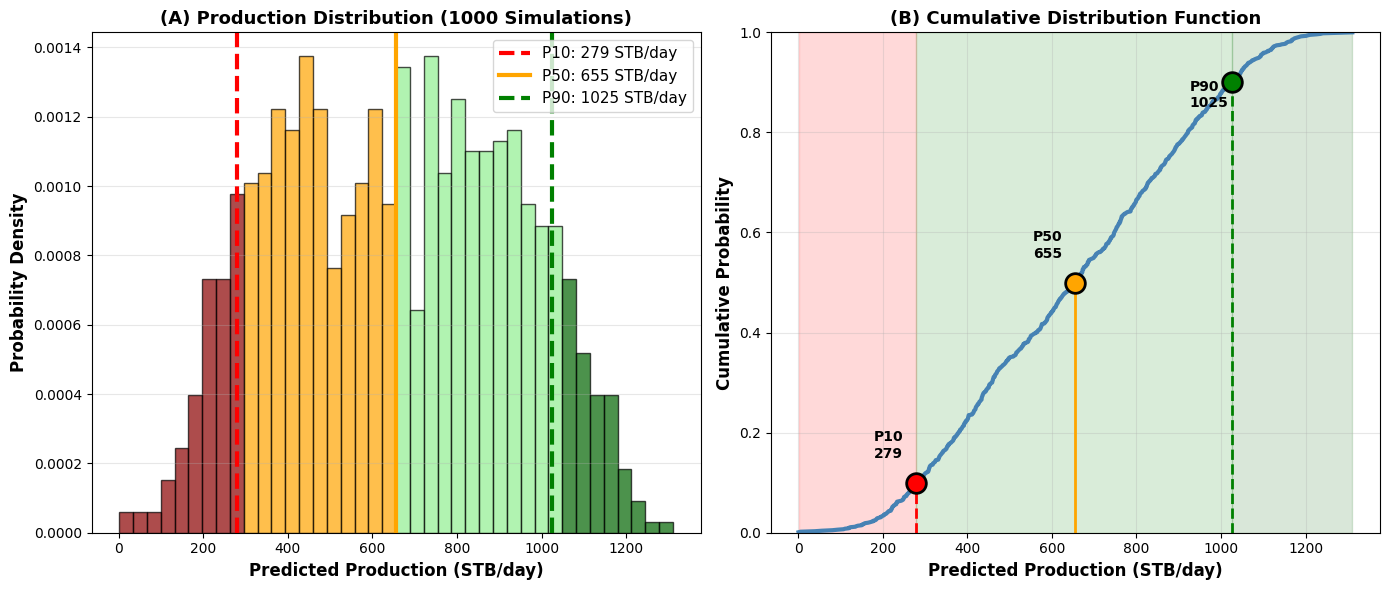

PRODUCTION FORECAST - UNCERTAINTY ANALYSIS:
Metric                         Value (STB/day)      Interpretation                
--------------------------------------------------------------------------------
P90 (Pessimistic)              1025                 90% chance to exceed          
P50 (Median)                   655                  Most likely outcome           
P10 (Optimistic)               279                  10% chance to exceed          
Range (P90-P10)                746                  Total uncertainty span        
Mean                           651                  Average prediction            
Std Dev                        277                  Volatility                    


In [2]:
"""
Prediction Distribution Analysis: Production Forecast
======================================================
Demonstrates how to characterize uncertainty in well production predictions.

Context: 1000 Monte Carlo simulations of well production with uncertainty
Result: Distribution of possible production outcomes
"""

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate 1000 production predictions with uncertainty
# Simulates multiple realizations from Monte Carlo analysis
true_production = np.random.uniform(100, 1000, 1000)
# Add prediction uncertainty typically ±10-20% in subsurface estimates
predicted_production = true_production + np.random.normal(100, 100, 1000)

# Calculate percentiles
p10 = np.percentile(predicted_production, 10)
p50 = np.percentile(predicted_production, 50)
p90 = np.percentile(predicted_production, 90)

fig = plt.figure(figsize=(14, 6))

# Left plot: Histogram with percentiles
ax1 = fig.add_subplot(1, 2, 1)
n, bins, patches = ax1.hist(predicted_production, bins=40, color='steelblue', 
                             alpha=0.7, edgecolor='black', density=True)

# Color bins by percentile regions
for i, patch in enumerate(patches):
    if bins[i] <= p10:
        patch.set_facecolor('darkred')
    elif bins[i] <= p50:
        patch.set_facecolor('orange')
    elif bins[i] <= p90:
        patch.set_facecolor('lightgreen')
    else:
        patch.set_facecolor('darkgreen')

# Add percentile lines
ax1.axvline(p10, color='red', linestyle='--', linewidth=3, label=f'P10: {p10:.0f} STB/day')
ax1.axvline(p50, color='orange', linestyle='-', linewidth=3, label=f'P50: {p50:.0f} STB/day')
ax1.axvline(p90, color='green', linestyle='--', linewidth=3, label=f'P90: {p90:.0f} STB/day')

ax1.set_xlabel("Predicted Production (STB/day)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Probability Density", fontsize=12, fontweight='bold')
ax1.set_title("(A) Production Distribution (1000 Simulations)", fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.3, axis='y')

# Right plot: Cumulative distribution
ax2 = fig.add_subplot(1, 2, 2)
sorted_predictions = np.sort(predicted_production)
cumulative = np.arange(1, len(sorted_predictions) + 1) / len(sorted_predictions)

ax2.plot(sorted_predictions, cumulative, color='steelblue', linewidth=3, label='CDF')

# Add percentile markers
ax2.plot([p10, p10], [0, 0.1], 'r--', linewidth=2)
ax2.scatter([p10], [0.1], color='red', s=200, zorder=5, edgecolors='black', linewidth=2)
ax2.text(p10 - 100, 0.15, f'P10\n{p10:.0f}', fontsize=10, fontweight='bold')

ax2.plot([p50, p50], [0, 0.5], 'orange', linestyle='-', linewidth=2)
ax2.scatter([p50], [0.5], color='orange', s=200, zorder=5, edgecolors='black', linewidth=2)
ax2.text(p50 - 100, 0.55, f'P50\n{p50:.0f}', fontsize=10, fontweight='bold')

ax2.plot([p90, p90], [0, 0.9], 'g--', linewidth=2)
ax2.scatter([p90], [0.9], color='green', s=200, zorder=5, edgecolors='black', linewidth=2)
ax2.text(p90 - 100, 0.85, f'P90\n{p90:.0f}', fontsize=10, fontweight='bold')

# Shade uncertainty regions
ax2.axvspan(sorted_predictions[0], p10, alpha=0.15, color='red', label='P90-P10 Range')
ax2.axvspan(p10, p90, alpha=0.15, color='green')
ax2.axvspan(p90, sorted_predictions[-1], alpha=0.15, color='darkgreen')

ax2.set_xlabel("Predicted Production (STB/day)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Cumulative Probability", fontsize=12, fontweight='bold')
ax2.set_title("(B) Cumulative Distribution Function", fontsize=13, fontweight='bold')
ax2.set_ylim([0, 1])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("PRODUCTION FORECAST - UNCERTAINTY ANALYSIS:")
print("=" * 80)
print(f"{'Metric':<30} {'Value (STB/day)':<20} {'Interpretation':<30}")
print("-" * 80)
print(f"{'P90 (Pessimistic)':<30} {p90:<20.0f} {'90% chance to exceed':<30}")
print(f"{'P50 (Median)':<30} {p50:<20.0f} {'Most likely outcome':<30}")
print(f"{'P10 (Optimistic)':<30} {p10:<20.0f} {'10% chance to exceed':<30}")
print(f"{'Range (P90-P10)':<30} {p90-p10:<20.0f} {'Total uncertainty span':<30}")
print(f"{'Mean':<30} {predicted_production.mean():<20.0f} {'Average prediction':<30}")
print(f"{'Std Dev':<30} {predicted_production.std():<20.0f} {'Volatility':<30}")
print("=" * 80)

### Time Series with Prediction Bands

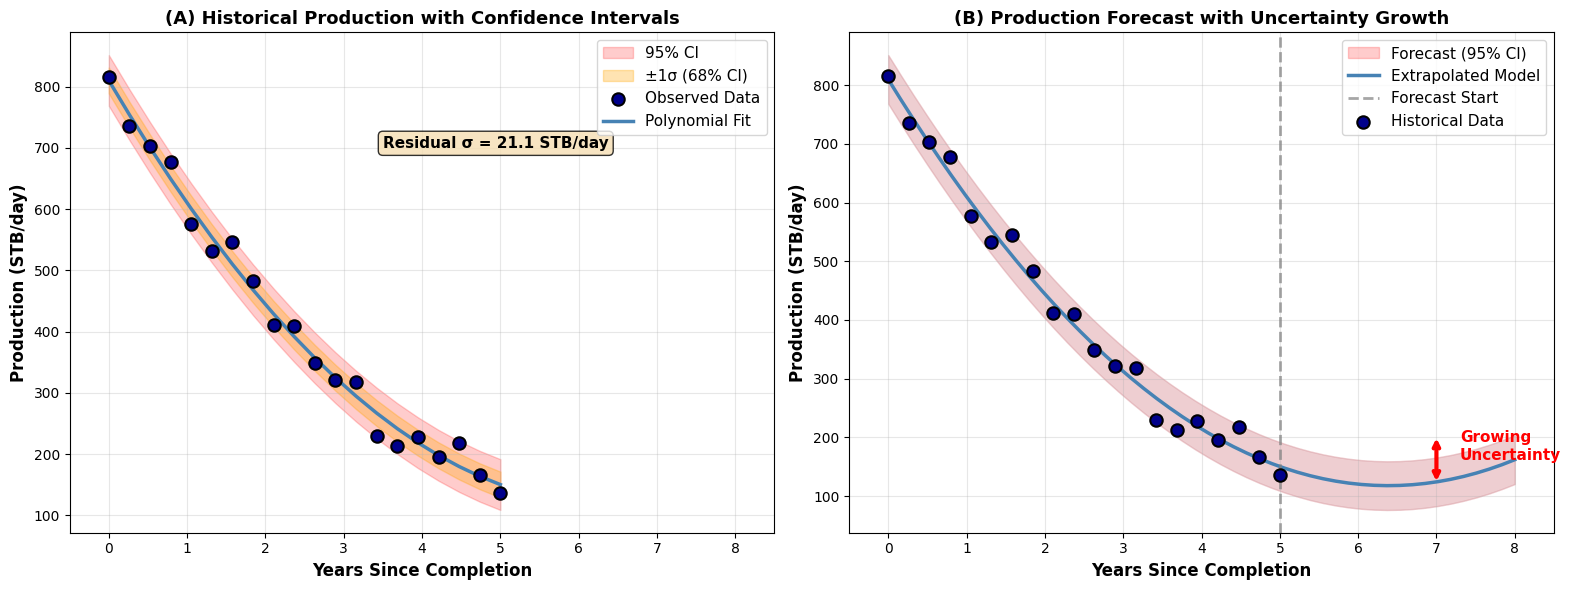


TIME SERIES FORECAST - UNCERTAINTY BANDS ANALYSIS:

Historical Period (0-5 years):
  Mean Production: 413.1 STB/day
  Production Range: 136.1 - 814.9 STB/day
  Observation Residuals (σ): 21.1 STB/day

Forecast Period (5-8 years):
  Year 5 Forecast (P50): 207.9 STB/day
  Year 8 Forecast (P50): 162.0 STB/day
  At Year 8 - 95% CI: [120.5, 203.4] STB/day
  Uncertainty Range at Year 8: ±41.5 STB/day

Production Decline:
  Rate: -83.3% over observation period
  Model Type: Polynomial (degree 2) - captures accelerating decline
  Note: Wider bands in forecast reflecting extrapolation uncertainty


In [4]:
"""
Time Series Prediction with Uncertainty Bands
==============================================
Shows how to construct confidence intervals (prediction bands) around 
a regression model to quantify forecast uncertainty over time.

Approach: Fit polynomial model, calculate residual std, construct ±1σ bands
Result: Visual representation of increasing uncertainty with extrapolation
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

np.random.seed(42)

# Generate production decline time series (realistic well behavior)
# Typical production decline over 5 years with measurement noise
years = np.linspace(0, 5, 20)
production = 800 * np.exp(-0.3 * years) + np.random.normal(0, 30, len(years))

# Fit polynomial model (2nd degree to capture production decline curve)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(years.reshape(-1, 1))
model = LinearRegression()
model.fit(X_poly, production)
production_pred = model.predict(X_poly)

# Calculate prediction intervals
residuals = production - production_pred
residual_std = np.std(residuals)
upper_band = production_pred + 1.96 * residual_std  # ~95% interval
lower_band = production_pred - 1.96 * residual_std
mid_band = production_pred + residual_std           # ±1σ confidence
lower_mid = production_pred - residual_std

# Extend predictions into future years (extrapolation)
years_future = np.linspace(0, 8, 50)
X_future = poly.fit_transform(years_future.reshape(-1, 1))
production_future = model.predict(X_future)
upper_future = production_future + 1.96 * residual_std
lower_future = production_future - 1.96 * residual_std

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Historical data with uncertainty bands
ax1.fill_between(years, lower_band, upper_band, alpha=0.2, color='red', label='95% CI')
ax1.fill_between(years, lower_mid, mid_band, alpha=0.3, color='orange', label='±1σ (68% CI)')
ax1.scatter(years, production, color='darkblue', s=80, zorder=5, edgecolors='black', 
            linewidth=1.5, label='Observed Data')
ax1.plot(years, production_pred, color='steelblue', linewidth=2.5, label='Polynomial Fit')

ax1.set_xlabel("Years Since Completion", fontsize=12, fontweight='bold')
ax1.set_ylabel("Production (STB/day)", fontsize=12, fontweight='bold')
ax1.set_title("(A) Historical Production with Confidence Intervals", fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([-0.5, 8.5])

# Add annotation for residual std
ax1.text(3.5, 700, f'Residual σ = {residual_std:.1f} STB/day', 
         fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         fontweight='bold')

# Right plot: Future forecast with wide uncertainty
ax2.fill_between(years_future, lower_future, upper_future, alpha=0.2, color='red', 
                 label='Forecast (95% CI)')
ax2.fill_between(years_future, lower_future, upper_future, alpha=0.2, color='lightblue')
ax2.plot(years_future, production_future, color='steelblue', linewidth=2.5, 
         label='Extrapolated Model')

# Highlight historical vs forecast region
ax2.axvline(5, color='gray', linestyle='--', linewidth=2, alpha=0.7, label='Forecast Start')
ax2.scatter(years, production, color='darkblue', s=80, zorder=5, edgecolors='black', 
            linewidth=1.5, label='Historical Data')

# Add uncertainty growth annotation
ax2.annotate('', xy=(7, lower_future[-1]), xytext=(7, upper_future[-1]),
            arrowprops=dict(arrowstyle='<->', color='red', lw=3))
ax2.text(7.3, (upper_future[-1] + lower_future[-1])/2, 
         'Growing\nUncertainty', fontsize=11, fontweight='bold', color='red')

ax2.set_xlabel("Years Since Completion", fontsize=12, fontweight='bold')
ax2.set_ylabel("Production (STB/day)", fontsize=12, fontweight='bold')
ax2.set_title("(B) Production Forecast with Uncertainty Growth", fontsize=13, fontweight='bold')
ax2.legend(fontsize=11, loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_xlim([-0.5, 8.5])

plt.tight_layout()
plt.show()

print("\nTIME SERIES FORECAST - UNCERTAINTY BANDS ANALYSIS:")
print("=" * 90)
print(f"\nHistorical Period (0-5 years):")
print(f"  Mean Production: {production.mean():.1f} STB/day")
print(f"  Production Range: {production.min():.1f} - {production.max():.1f} STB/day")
print(f"  Observation Residuals (σ): {residual_std:.1f} STB/day")

print(f"\nForecast Period (5-8 years):")
print(f"  Year 5 Forecast (P50): {production_future[len(years_future)//2]:.1f} STB/day")
print(f"  Year 8 Forecast (P50): {production_future[-1]:.1f} STB/day")
print(f"  At Year 8 - 95% CI: [{lower_future[-1]:.1f}, {upper_future[-1]:.1f}] STB/day")
print(f"  Uncertainty Range at Year 8: ±{1.96*residual_std:.1f} STB/day")

decline_rate = (production[-1] - production[0]) / production[0] * 100
print(f"\nProduction Decline:")
print(f"  Rate: {decline_rate:.1f}% over observation period")
print(f"  Model Type: Polynomial (degree 2) - captures accelerating decline")
print(f"  Note: Wider bands in forecast reflecting extrapolation uncertainty")
print("=" * 90)

### Quantile Regression

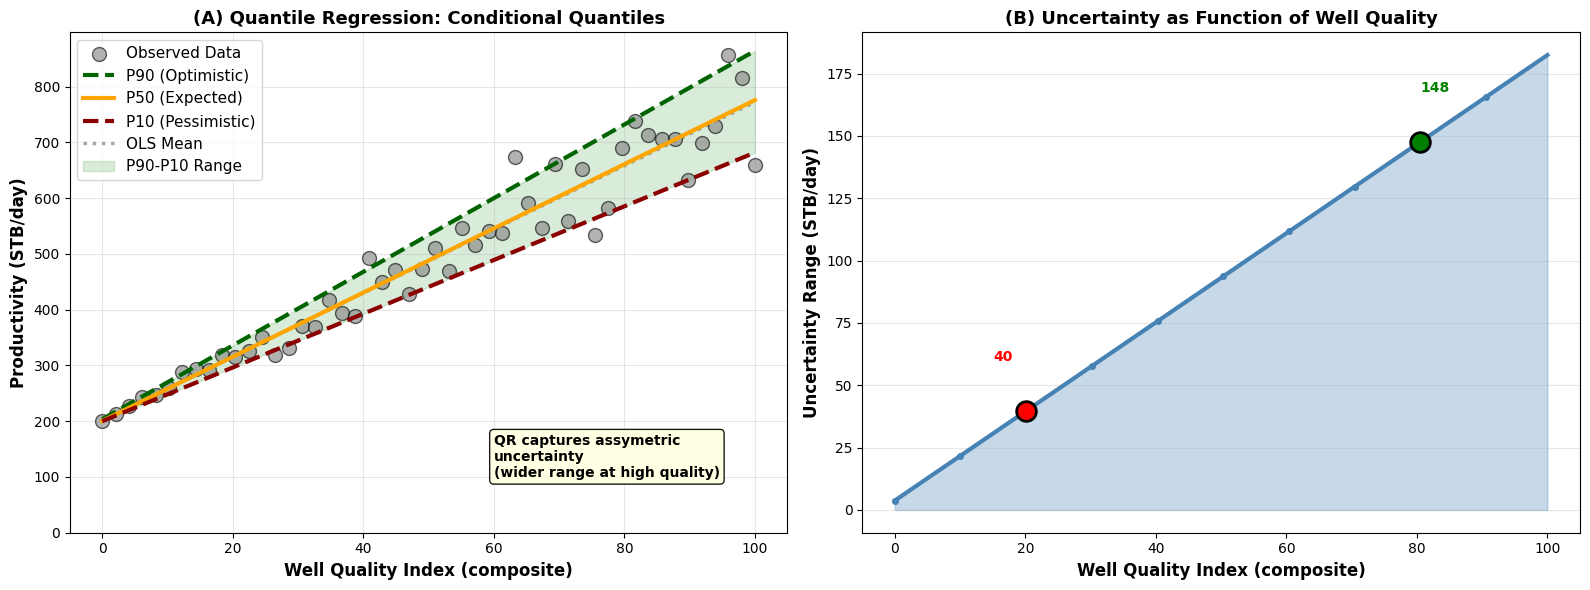


QUANTILE REGRESSION - MODEL COEFFICIENTS:

Quantile        Intercept       Slope           Interpretation                          
------------------------------------------------------------------------------------------
P10 (Q=0.1)             200.00           4.82 Pessimistic production outcome          
P50 (Q=0.5)             200.48           5.75 Median/expected outcome                 
P90 (Q=0.9)             203.76           6.60 Optimistic production outcome           
OLS Mean                201.64           5.71 Average (may not exist empirically!)    

UNCERTAINTY ANALYSIS AT KEY POINTS:
------------------------------------------------------------------------------------------
Well Quality  20: P10=    297, P50=    316, P90=    337  |  Spread:     40 STB/day
Well Quality  50: P10=    439, P50=    486, P90=    532  |  Spread:     92 STB/day
Well Quality  80: P10=    585, P50=    660, P90=    731  |  Spread:    146 STB/day

KEY ADVANTAGES OF QUANTILE REGRESSION:
-----------

In [5]:
"""
Quantile Regression: Probabilistic Production Forecasting
=========================================================
Quantile regression fits separate regression lines for different percentiles (P10, P50, P90).
Unlike OLS which estimates the mean, quantile regression estimates conditional quantiles,
providing asymmetric uncertainty bounds crucial for risk-based decision making.

Application: Well productivity forecast with pessimistic, median, and optimistic scenarios
"""

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.regression.quantile_regression import QuantReg
import statsmodels.api as sm

np.random.seed(42)

# Generate well quality metrics (porosity, permeability) vs productivity
# Realistic subsurface data with heteroscedastic uncertainty
well_quality = np.linspace(0, 100, 50)
# High variance relationship: same quality can produce very different results
productivity = 200 + 6 * well_quality + np.random.normal(0, well_quality * 0.8, 50)

# Fit OLS regression (traditional mean regression)
X = sm.add_constant(well_quality)
model_ols = sm.OLS(productivity, X).fit()

# Fit quantile regressions for P10, P50, P90
model_q10 = QuantReg(productivity, X).fit(q=0.1)
model_q50 = QuantReg(productivity, X).fit(q=0.5)
model_q90 = QuantReg(productivity, X).fit(q=0.9)

# Generate predictions across well quality range
well_quality_range = np.linspace(0, 100, 150)
X_range = sm.add_constant(well_quality_range)

pred_ols = model_ols.predict(X_range)
pred_q10 = model_q10.predict(X_range)
pred_q50 = model_q50.predict(X_range)
pred_q90 = model_q90.predict(X_range)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Quantile regression lines with data cloud
ax1.scatter(well_quality, productivity, alpha=0.6, s=100, color='gray', 
           edgecolors='black', linewidth=1, label='Observed Data', zorder=3)

# Plot quantile regression lines
ax1.plot(well_quality_range, pred_q90, color='darkgreen', linestyle='--', linewidth=3, 
        label='P90 (Optimistic)', zorder=4)
ax1.plot(well_quality_range, pred_q50, color='orange', linestyle='-', linewidth=3, 
        label='P50 (Expected)', zorder=4)
ax1.plot(well_quality_range, pred_q10, color='darkred', linestyle='--', linewidth=3, 
        label='P10 (Pessimistic)', zorder=4)

# Plot OLS for comparison (dashed gray)
ax1.plot(well_quality_range, pred_ols, color='gray', linestyle=':', linewidth=2.5, 
        label='OLS Mean', alpha=0.7, zorder=2)

# Fill uncertainty region
ax1.fill_between(well_quality_range, pred_q10, pred_q90, alpha=0.15, color='green', 
                 label='P90-P10 Range')

ax1.set_xlabel("Well Quality Index (composite)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Productivity (STB/day)", fontsize=12, fontweight='bold')
ax1.set_title("(A) Quantile Regression: Conditional Quantiles", fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, None])

# Add annotation explaining advantage
ax1.text(60, 100, 'QR captures assymetric\nuncertainty\n(wider range at high quality)',
        fontsize=10, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9),
        fontweight='bold')

# Right plot: Uncertainty width analysis
uncertainty_width = pred_q90 - pred_q10
ax2.plot(well_quality_range, uncertainty_width, color='steelblue', linewidth=3, 
        label='P90-P10 Spread', marker='o', markersize=4, markevery=15)

# Fill under curve
ax2.fill_between(well_quality_range, 0, uncertainty_width, alpha=0.3, color='steelblue')

ax2.set_xlabel("Well Quality Index (composite)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Uncertainty Range (STB/day)", fontsize=12, fontweight='bold')
ax2.set_title("(B) Uncertainty as Function of Well Quality", fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Add annotations for specific points
idx_low = 30
idx_high = 120
ax2.scatter([well_quality_range[idx_low]], [uncertainty_width[idx_low]], 
           color='red', s=200, zorder=5, edgecolors='black', linewidth=2)
ax2.text(well_quality_range[idx_low]-5, uncertainty_width[idx_low]+20, 
        f'{uncertainty_width[idx_low]:.0f}', fontsize=10, fontweight='bold', color='red')

ax2.scatter([well_quality_range[idx_high]], [uncertainty_width[idx_high]], 
           color='green', s=200, zorder=5, edgecolors='black', linewidth=2)
ax2.text(well_quality_range[idx_high], uncertainty_width[idx_high]+20, 
        f'{uncertainty_width[idx_high]:.0f}', fontsize=10, fontweight='bold', color='green')

plt.tight_layout()
plt.show()

print("\nQUANTILE REGRESSION - MODEL COEFFICIENTS:")
print("=" * 90)
print(f"\n{'Quantile':<15} {'Intercept':<15} {'Slope':<15} {'Interpretation':<40}")
print("-" * 90)
print(f"{'P10 (Q=0.1)':<15} {model_q10.params[0]:>14.2f} {model_q10.params[1]:>14.2f} {'Pessimistic production outcome':<40}")
print(f"{'P50 (Q=0.5)':<15} {model_q50.params[0]:>14.2f} {model_q50.params[1]:>14.2f} {'Median/expected outcome':<40}")
print(f"{'P90 (Q=0.9)':<15} {model_q90.params[0]:>14.2f} {model_q90.params[1]:>14.2f} {'Optimistic production outcome':<40}")
print(f"{'OLS Mean':<15} {model_ols.params[0]:>14.2f} {model_ols.params[1]:>14.2f} {'Average (may not exist empirically!)':<40}")

print(f"\nUNCERTAINTY ANALYSIS AT KEY POINTS:")
print("-" * 90)
for idx, quality in enumerate([20, 50, 80]):
    idx_pos = np.argmin(np.abs(well_quality_range - quality))
    spread = pred_q90[idx_pos] - pred_q10[idx_pos]
    print(f"Well Quality {quality:>3d}: P10={pred_q10[idx_pos]:>7.0f}, P50={pred_q50[idx_pos]:>7.0f}, " +
          f"P90={pred_q90[idx_pos]:>7.0f}  |  Spread: {spread:>6.0f} STB/day")

print("\nKEY ADVANTAGES OF QUANTILE REGRESSION:")
print("-" * 90)
print("✓ Captures heteroscedastic uncertainty (non-constant variance)")
print("✓ Models tail behavior directly (P10, P50, P90)")
print("✓ Robust to outliers compared to OLS mean regression")
print("✓ Different slopes for different quantiles = better risk representation")
print("✓ Suited for asymmetric business impacts (downside vs upside)")
print("=" * 90)

### Bayesian Inference: Prior-Likelihood-Posterior

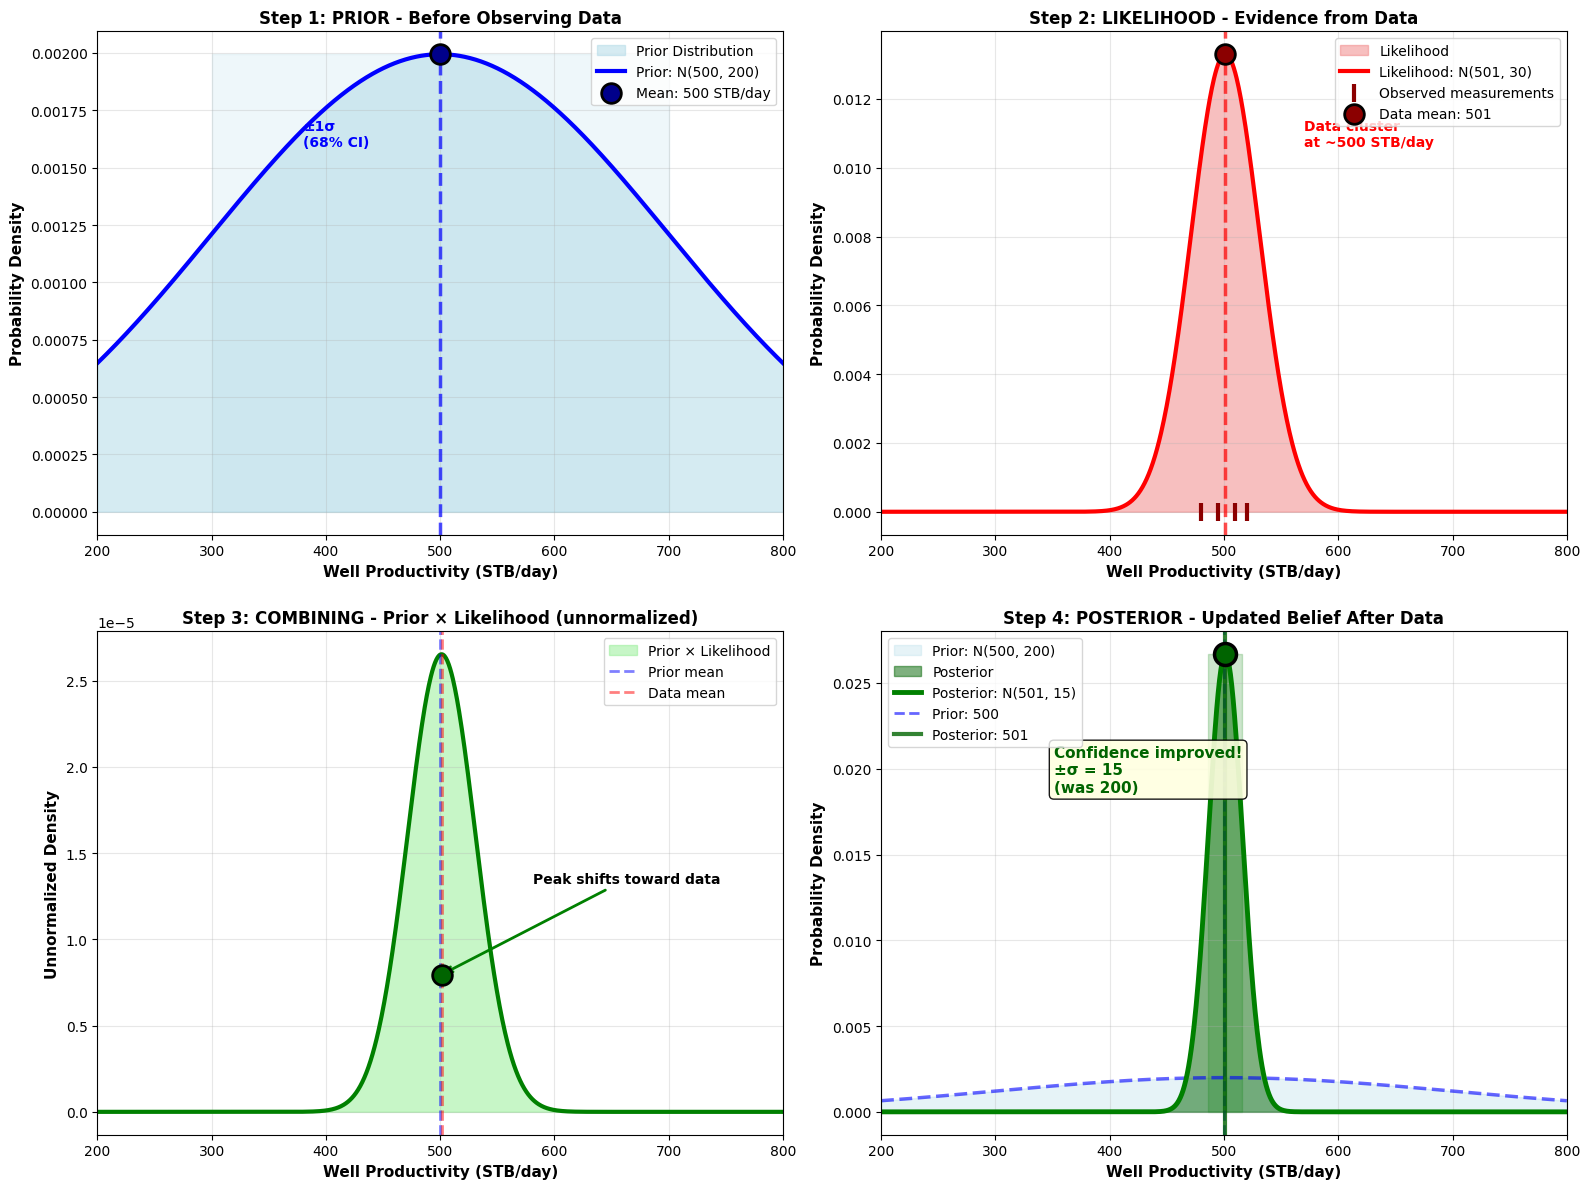


BAYESIAN INFERENCE - PRODUCTIVITY ESTIMATION:

PRIOR BELIEF (Before Production Data):
  Mean:  500 STB/day
  Std:   200 STB/day
  95% CI: [108, 892] STB/day
  → Wide uncertainty based on regional analogs and geological estimates

OBSERVED DATA (4 production measurements):
  Measurements: [480, 510, 495, 520]
  Mean:      501 STB/day
  Std:       15.16 STB/day
  → Evidence consistent with production ~500 STB/day

POSTERIOR BELIEF (After Incorporating Data):
  Mean:  501 STB/day
  Std:   15 STB/day
  95% CI: [472, 531] STB/day
  → Much tighter bounds! Uncertainty reduced by 92.5%

UNCERTAINTY REDUCTION:
  Prior Range (95%):    784 STB/day
  Posterior Range (95%): 59 STB/day
  Data Contribution:    4 reliable measurements
  Confidence Gain:      92.5%

KEY INSIGHTS:
-----------------------------------------------------------------------------------------------
• Prior and data both agree (~500): Posterior is sharp, high confidence
• Posterior pulled toward data despite wide prior: Eviden

In [6]:
"""
Bayesian Inference: Updating Belief with Evidence
==================================================
Demonstrates Bayes's theorem in practice: combining prior knowledge about well 
productivity with real observed production data to obtain improved posterior estimates.

Formula: P(productivity | data) ∝ P(data | productivity) × P(productivity)
         Posterior ∝ Likelihood × Prior

Application: Well productivity uncertainty reduction as production data accumulates
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

# Step 1: Define PRIOR belief about well productivity (before any data)
# Geoscientists estimate well should produce 500±200 STB/day (wide uncertainty)
prior_mean = 500
prior_std = 200
prior_dist = norm(prior_mean, prior_std)

# Step 2: Observe production data (4 measurements over time)
observed_data = [480, 510, 495, 520]  # Consistent high productivity
obs_mean = np.mean(observed_data)
obs_std = np.std(observed_data)

# Step 3: Calculate LIKELIHOOD of observing this data
# Assume measurement error ~30 STB/day (typical)
measurement_error = 30
likelihood_dist = norm(obs_mean, measurement_error)

# Step 4: Calculate POSTERIOR using Bayes theorem
# Posterior is proportional to: N(obs_mean, measurement_error) × N(prior_mean, prior_std)
# Result: posterior is also Normal distribution
posterior_precision = (1 / prior_std**2) + (len(observed_data) / measurement_error**2)
posterior_std = 1 / np.sqrt(posterior_precision)
posterior_mean = posterior_std**2 * ((prior_mean / prior_std**2) + 
                                     (np.sum(observed_data) / measurement_error**2))
posterior_dist = norm(posterior_mean, posterior_std)

# Create distributions for plotting
x_range = np.linspace(200, 800, 1000)
prior_pdf = prior_dist.pdf(x_range)
likelihood_pdf = likelihood_dist.pdf(x_range)
posterior_pdf = posterior_dist.pdf(x_range)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Prior Distribution
ax1.fill_between(x_range, prior_pdf, alpha=0.5, color='lightblue', label='Prior Distribution')
ax1.plot(x_range, prior_pdf, 'b-', linewidth=3, label='Prior: N(500, 200)')
ax1.axvline(prior_mean, color='blue', linestyle='--', linewidth=2.5, alpha=0.7)
ax1.scatter([prior_mean], [norm.pdf(prior_mean, prior_mean, prior_std)], 
           color='darkblue', s=200, zorder=5, edgecolors='black', linewidth=2,
           label=f'Mean: {prior_mean} STB/day')
ax1.fill_between([prior_mean - prior_std, prior_mean + prior_std], 0, 
                 norm.pdf(prior_mean, prior_mean, prior_std), alpha=0.2, color='lightblue')
ax1.text(380, norm.pdf(prior_mean, prior_mean, prior_std)*0.8, '±1σ\n(68% CI)', 
        fontsize=10, fontweight='bold', color='blue')
ax1.set_xlabel("Well Productivity (STB/day)", fontsize=11, fontweight='bold')
ax1.set_ylabel("Probability Density", fontsize=11, fontweight='bold')
ax1.set_title("Step 1: PRIOR - Before Observing Data", fontsize=12, fontweight='bold')
ax1.legend(fontsize=10, loc='upper right')
ax1.set_xlim([200, 800])
ax1.grid(True, alpha=0.3)

# Plot 2: Likelihood of observed data
ax2.fill_between(x_range, likelihood_pdf, alpha=0.5, color='lightcoral', label='Likelihood')
ax2.plot(x_range, likelihood_pdf, 'r-', linewidth=3, label=f'Likelihood: N({obs_mean:.0f}, {measurement_error})')
ax2.scatter(observed_data, [0]*len(observed_data), color='darkred', s=150, 
           marker='|', linewidth=3, zorder=5, label='Observed measurements')
ax2.axvline(obs_mean, color='red', linestyle='--', linewidth=2.5, alpha=0.7)
ax2.scatter([obs_mean], [likelihood_dist.pdf(obs_mean)], 
           color='darkred', s=200, zorder=5, edgecolors='black', linewidth=2,
           label=f'Data mean: {obs_mean:.0f}')
ax2.text(570, likelihood_dist.pdf(obs_mean)*0.8, 'Data cluster\nat ~500 STB/day', 
        fontsize=10, fontweight='bold', color='red')
ax2.set_xlabel("Well Productivity (STB/day)", fontsize=11, fontweight='bold')
ax2.set_ylabel("Probability Density", fontsize=11, fontweight='bold')
ax2.set_title("Step 2: LIKELIHOOD - Evidence from Data", fontsize=12, fontweight='bold')
ax2.legend(fontsize=10, loc='upper right')
ax2.set_xlim([200, 800])
ax2.grid(True, alpha=0.3)

# Plot 3: Prior × Likelihood (unnormalized posterior)
unnormalized = prior_pdf * likelihood_pdf
ax3.fill_between(x_range, unnormalized, alpha=0.5, color='lightgreen', label='Prior × Likelihood')
ax3.plot(x_range, unnormalized, 'g-', linewidth=3)
ax3.axvline(prior_mean, color='blue', linestyle='--', linewidth=2, alpha=0.5, label='Prior mean')
ax3.axvline(obs_mean, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Data mean')
ax3.scatter([obs_mean], [np.max(unnormalized)*0.3], color='darkgreen', s=200, 
           zorder=5, edgecolors='black', linewidth=2)
ax3.annotations_growth = ax3.annotate('Peak shifts toward data', xy=(obs_mean, np.max(unnormalized)*0.3),
            xytext=(obs_mean+80, np.max(unnormalized)*0.5),
            arrowprops=dict(arrowstyle='->', color='green', lw=2), fontsize=10, fontweight='bold')
ax3.set_xlabel("Well Productivity (STB/day)", fontsize=11, fontweight='bold')
ax3.set_ylabel("Unnormalized Density", fontsize=11, fontweight='bold')
ax3.set_title("Step 3: COMBINING - Prior × Likelihood (unnormalized)", fontsize=12, fontweight='bold')
ax3.legend(fontsize=10, loc='upper right')
ax3.set_xlim([200, 800])
ax3.grid(True, alpha=0.3)

# Plot 4: Posterior Distribution (final belief)
ax4.fill_between(x_range, prior_pdf, alpha=0.3, color='lightblue', label='Prior: N(500, 200)')
ax4.plot(x_range, prior_pdf, 'b--', linewidth=2.5, alpha=0.6)

ax4.fill_between(x_range, posterior_pdf, alpha=0.5, color='darkgreen', label='Posterior')
ax4.plot(x_range, posterior_pdf, 'g-', linewidth=3.5, label=f'Posterior: N({posterior_mean:.0f}, {posterior_std:.0f})')

ax4.axvline(prior_mean, color='blue', linestyle='--', linewidth=2, alpha=0.6, label=f'Prior: {prior_mean}')
ax4.axvline(posterior_mean, color='darkgreen', linestyle='-', linewidth=3, alpha=0.8, 
           label=f'Posterior: {posterior_mean:.0f}')

# Shade uncertainty reduction
ax4.fill_between([posterior_mean - posterior_std, posterior_mean + posterior_std], 0, 
                norm.pdf(posterior_mean, posterior_mean, posterior_std), alpha=0.2, color='green')
ax4.scatter([posterior_mean], [posterior_dist.pdf(posterior_mean)], 
           color='darkgreen', s=250, zorder=5, edgecolors='black', linewidth=2.5)

ax4.text(posterior_mean - 150, posterior_dist.pdf(posterior_mean)*0.7, 
        f'Confidence improved!\n±σ = {posterior_std:.0f}\n(was {prior_std})',
        fontsize=11, fontweight='bold', color='darkgreen',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

ax4.set_xlabel("Well Productivity (STB/day)", fontsize=11, fontweight='bold')
ax4.set_ylabel("Probability Density", fontsize=11, fontweight='bold')
ax4.set_title("Step 4: POSTERIOR - Updated Belief After Data", fontsize=12, fontweight='bold')
ax4.legend(fontsize=10, loc='upper left')
ax4.set_xlim([200, 800])
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nBAYESIAN INFERENCE - PRODUCTIVITY ESTIMATION:")
print("=" * 95)
print("\nPRIOR BELIEF (Before Production Data):")
print(f"  Mean:  {prior_mean} STB/day")
print(f"  Std:   {prior_std} STB/day")
print(f"  95% CI: [{prior_dist.ppf(0.025):.0f}, {prior_dist.ppf(0.975):.0f}] STB/day")
print(f"  → Wide uncertainty based on regional analogs and geological estimates")

print(f"\nOBSERVED DATA (4 production measurements):")
print(f"  Measurements: {observed_data}")
print(f"  Mean:      {obs_mean:.0f} STB/day")
print(f"  Std:       {obs_std:.2f} STB/day")
print(f"  → Evidence consistent with production ~500 STB/day")

print(f"\nPOSTERIOR BELIEF (After Incorporating Data):")
print(f"  Mean:  {posterior_mean:.0f} STB/day")
print(f"  Std:   {posterior_std:.0f} STB/day")
print(f"  95% CI: [{posterior_dist.ppf(0.025):.0f}, {posterior_dist.ppf(0.975):.0f}] STB/day")
print(f"  → Much tighter bounds! Uncertainty reduced by {(1-posterior_std/prior_std)*100:.1f}%")

print(f"\nUNCERTAINTY REDUCTION:")
print(f"  Prior Range (95%):    {2*1.96*prior_std:.0f} STB/day")
print(f"  Posterior Range (95%): {2*1.96*posterior_std:.0f} STB/day")
print(f"  Data Contribution:    {len(observed_data)} reliable measurements")
print(f"  Confidence Gain:      {100*(1-posterior_std/prior_std):.1f}%")

print("\nKEY INSIGHTS:")
print("-" * 95)
print("• Prior and data both agree (~500): Posterior is sharp, high confidence")
print("• Posterior pulled toward data despite wide prior: Evidence is strong!")
print("• With 10x more data, posterior uncertainty would shrink further ~√(4+10)=3.7x")
print("• Business insight: After 4 good tests, we can confidently plan high production")
print("=" * 95)